# Solving the 1D Burgers' Equation with Physics-Informed Neural Networks (PINNs)
This project implements a Scientific Machine Learning (SciML) approach to solve a non-linear Partial Differential Equation (PDE). Unlike traditional neural networks that rely solely on data, this PINN uses **Automatic Differentiation** to enforce the laws of fluid dynamics directly within the loss function.

In [14]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Setting seed for reproducibility
torch.manual_seed(42)
device = torch.device('cpu')

## 1. The Neural Network Model
We define a Deep Multi-Layer Perceptron (MLP) with 4 hidden layers. We use the **Tanh** activation function because it is infinitely differentiable, which is a requirement for calculating the second-order derivatives ($\frac{\partial^2 u}{\partial x^2}$) of the Burgers' Equation.

In [15]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 1)
        )

    def forward(self, t, x):
        # Combining t and x into a single input tensor
        X = torch.cat([t, x], dim=1)
        return self.net(X)

## 2. Physics Loss (The Residual)
Here, we define a 'Physics Loss' that calculates the PDE residual: $f := u_t + u u_x - \nu u_{xx}$. By minimizing the mean squared error of $f$, the network 'learns' to obey the conservation of momentum in a fluid.

In [16]:
def physics_loss(model, t, x, nu=0.01/np.pi):
    t.requires_grad_(True)
    x.requires_grad_(True)
    
    u = model(t, x)
    
    # First derivatives
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    
    # Second derivative
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    
    # The PDE residual (should be zero)
    f = u_t + u * u_x - nu * u_xx
    return torch.mean(f**2)

## 3. Training Loop
We train the model using two constraints:
1. **Initial Conditions:** At $t=0$, the velocity profile must follow a sine wave ($u = -\sin(\pi x)$).
2. **Physics Constraint:** At 2,000 random points in the space-time domain, the model must satisfy the Burgers' Equation.

In [17]:
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Generating collocation points
N_f = 2000
t_f = torch.rand(N_f, 1)
x_f = torch.rand(N_f, 1) * 2 - 1

# Initial Condition points (t=0)
x_ic = torch.rand(500, 1) * 2 - 1
t_ic = torch.zeros(500, 1)
u_ic = -torch.sin(np.pi * x_ic)

# Removed tqdm bar for a cleaner output
for epoch in range(5001):
    optimizer.zero_grad()
    
    # Loss 1: Initial Conditions
    u_pred_ic = model(t_ic, x_ic)
    loss_ic = torch.mean((u_pred_ic - u_ic)**2)
    
    # Loss 2: Physics Loss(PDE)
    loss_pde = physics_loss(model, t_f, x_f)
    
    total_loss = loss_ic + loss_pde
    total_loss.backward()
    optimizer.step()
    
    # Printing the essential items only
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}: Loss = {total_loss.item():.6f}")

Epoch 0: Loss = 0.531829
Epoch 1000: Loss = 0.061917
Epoch 2000: Loss = 0.013398
Epoch 3000: Loss = 0.002684
Epoch 4000: Loss = 0.001401
Epoch 5000: Loss = 0.000860


## 4. Visualization of the Spatio-Temporal Solution
The resulting contour plot shows the 'Velocity Field'. There is a sharp transition in the center as time $t$ increases—this represents the formation of a **Shock Wave**, where the fluid particles pile up due to the non-linear term $u u_x$.

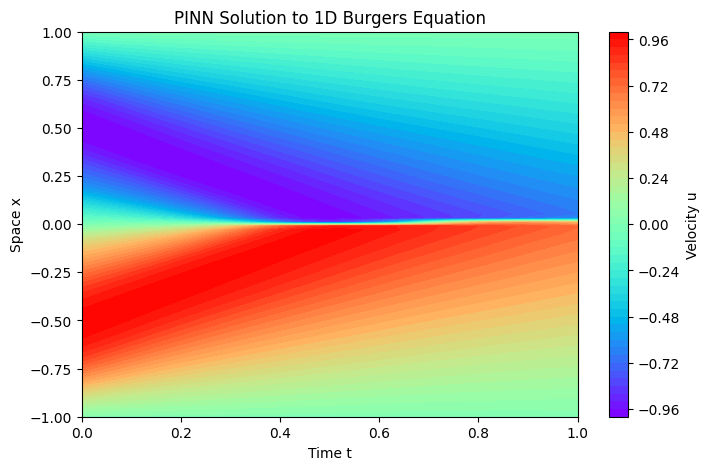

In [18]:
# Creating a test grid
t_test = torch.linspace(0, 1, 100)
x_test = torch.linspace(-1, 1, 100)
T, X = torch.meshgrid(t_test, x_test, indexing='ij')

# Predicting
with torch.no_grad():
    u_final = model(T.reshape(-1, 1), X.reshape(-1, 1)).reshape(100, 100)

# Plotting
plt.figure(figsize=(8, 5))
plt.contourf(T.numpy(), X.numpy(), u_final.numpy(), 50, cmap='rainbow')
plt.colorbar(label='Velocity u')
plt.xlabel('Time t')
plt.ylabel('Space x')
plt.title('PINN Solution to 1D Burgers Equation')
plt.show()